In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_1=pd.read_csv("train.csv")
df_2=pd.read_csv("test.csv")
if 'SalesPrice' not in df_2.columns:
    df_2['SalesPrice']=0
df=pd.concat([df_1, df_2], axis=0 )
df=df.set_index('Id')

In [5]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalesPrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,NaN
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,NaN
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0,NaN
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0,NaN
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0,NaN


In [6]:
df.isnull().sum()[df.isnull().sum()>0]

MSZoning           4
LotFrontage      486
Alley           2721
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType      1766
MasVnrArea        23
BsmtQual          81
BsmtCond          82
BsmtExposure      82
BsmtFinType1      79
BsmtFinSF1         1
BsmtFinType2      80
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu     1420
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2909
Fence           2348
MiscFeature     2814
SaleType           1
SalePrice       1459
SalesPrice      1460
dtype: int64

In [7]:
df_null=df[df.isnull().sum()[df.isnull().sum()>0].index]

In [8]:
df_null.head()

,MSZoning,LotFrontage,Alley,Utilities,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,BsmtQual,BsmtCond,...,GarageCars,GarageArea,GarageQual,GarageCond,PoolQC,Fence,MiscFeature,SaleType,SalePrice,SalesPrice
Id,,,,,,,,,,,,,,,,,,,,,
1,RL,65.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,...,2.0,548.0,TA,TA,NaN,NaN,NaN,WD,208500.0,NaN
2,RL,80.0,NaN,AllPub,MetalSd,MetalSd,NaN,0.0,Gd,TA,...,2.0,460.0,TA,TA,NaN,NaN,NaN,WD,181500.0,NaN
3,RL,68.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,...,2.0,608.0,TA,TA,NaN,NaN,NaN,WD,223500.0,NaN
4,RL,60.0,NaN,AllPub,Wd Sdng,Wd Shng,NaN,0.0,TA,Gd,...,3.0,642.0,TA,TA,NaN,NaN,NaN,WD,140000.0,NaN
5,RL,84.0,NaN,AllPub,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,...,3.0,836.0,TA,TA,NaN,NaN,NaN,WD,250000.0,NaN


<Axes: ylabel='Id'>

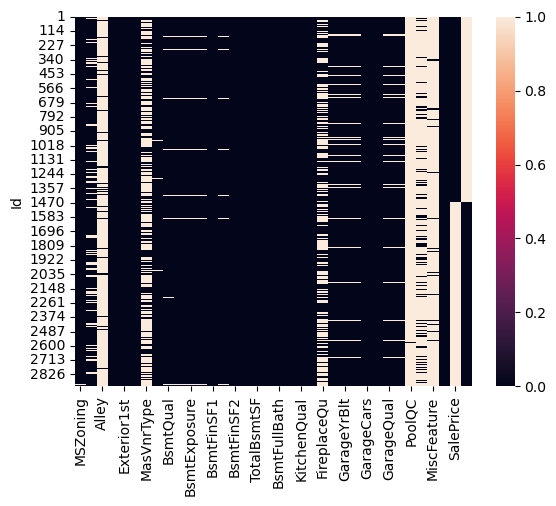

In [9]:
sns.heatmap(df_null.isnull())

In [19]:
df_objects=df[df.select_dtypes(include=['object']).columns]
df=df.drop(df[df_objects.isna().sum()[df_objects.isna().sum()>1100].index],axis=1)

In [20]:
df_objects=df_objects.drop(df_objects[df_objects.isna().sum()[df_objects.isna().sum()>1100].index],axis=1)
df_objects.head(3)
df_objects=df_objects.fillna('null')
df_objects_encoded=pd.get_dummies(df_objects)

In [21]:
df_objects['MSZoning'].value_counts()

MSZoning
RL         2265
RM          460
FV          139
RH           26
C (all)      25
null          4
Name: count, dtype: int64

In [22]:
df_objects_encoded.head(5)

,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,MSZoning_null,Street_Grvl,Street_Pave,LotShape_IR1,LotShape_IR2,...,SaleType_New,SaleType_Oth,SaleType_WD,SaleType_null,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
2,False,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
3,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False
4,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
5,False,False,False,True,False,False,False,True,True,False,...,False,False,True,False,False,False,False,False,True,False


In [23]:
for i in df_objects_encoded.columns:
    if 'null' in i:
        df_objects_encoded=df_objects_encoded.drop(i, axis=1)
        print(i)

MSZoning_null
Utilities_null
Exterior1st_null
Exterior2nd_null
BsmtQual_null
BsmtCond_null
BsmtExposure_null
BsmtFinType1_null
BsmtFinType2_null
Electrical_null
KitchenQual_null
Functional_null
GarageType_null
GarageFinish_null
GarageQual_null
GarageCond_null
SaleType_null


In [24]:
new_df=pd.concat([df, df_objects_encoded], axis=1)

In [25]:
len(new_df.columns)

305

In [26]:
new_df=new_df.drop(df.select_dtypes(include=['object']), axis=1)
new_df.isna().sum()[new_df.isna().sum()>0]




LotFrontage      486
MasVnrArea        23
BsmtFinSF1         1
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
BsmtFullBath       2
BsmtHalfBath       2
GarageYrBlt      159
GarageCars         1
GarageArea         1
SalePrice       1459
SalesPrice      1460
dtype: int64

In [27]:
Mode_columns=['GarageCars', 'GarageYrBlt', 'BsmtFullBath', 'BsmtHalfBath','BsmtFinSF2']
Mean_columns=['LotFrontage','MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', 'TotalBsmtSF','GarageArea', 'SalePrice', 'SalesPrice']
for i in Mode_columns:
    new_df[i]=new_df[i].fillna(new_df[i].mode()[0])
for i in Mean_columns:
    new_df[i]=new_df[i].fillna(new_df[i].mean())
new_df.isna().sum()[new_df.isna().sum()>0]

Series([], dtype: int64)

In [28]:
training_data=new_df[0: len(df_1)]
testing_data=new_df[len(df_1):]
testing_data=testing_data.drop(columns='SalePrice')

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [44]:
X=training_data.drop(columns='SalePrice')
y=training_data['SalePrice']
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2)
y_train=np.reshape(y_train.values,(-1,1))
y_test=np.reshape(y_test.values,(-1,1))
X_train.shape, y_train.shape

((1168, 267), (1168, 1))

In [45]:
model_1=LinearRegression()
model_1.fit(X,y)
y_pred=model_1.predict(X_test)
mean_squared_error(y_test,y_pred)

366975585.990156

In [46]:
model_2=XGBRegressor(n_estimators=1000, learning_rate=0.1, random_state=42)
model_2.fit(X,y)
y_pred=model_2.predict(X_test)
mean_squared_error(y_test,y_pred)

2437.7404827483715

In [47]:
model_3=RandomForestRegressor(n_estimators=100)
model_3.fit(X,y)
y_pred=model_3.predict(X_test)
mean_squared_error(y_test,y_pred)

97137480.493712

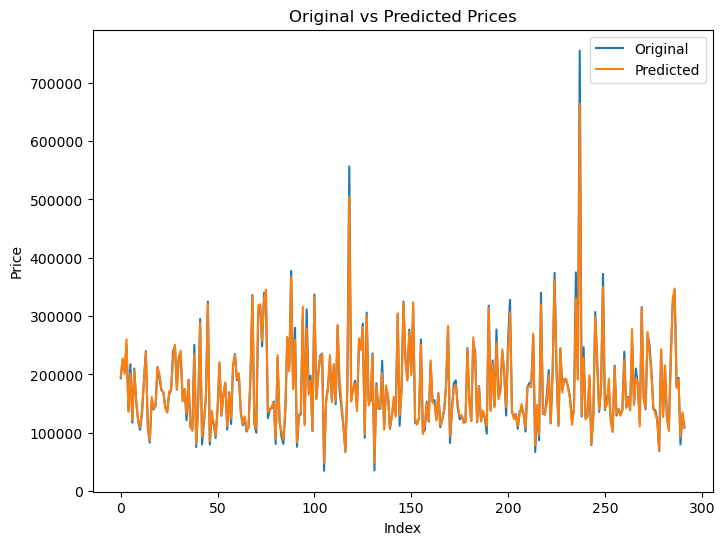

In [52]:
sort_indicates=np.argsort(y_test)
plt.figure(figsize=(8,6))
plt.plot(np.arange(len(y_test)), y_test, label='Original')
plt.plot(np.arange(len(y_test)), y_pred, label='Predicted')
plt.xlabel('Index')
plt.ylabel('Price')
plt.title("Original vs Predicted Prices")
plt.legend()
plt.show()

In [49]:
pred=model_1.predict(testing_data)
final=pd.DataFrame()
final['Id']=testing_data.index
final['SalePrice']=pred
# Write DataFrame to a CSV file without index
final.to_csv('output.csv', index=False)